<h1 align="center">
<strong><u>Senyals i Sistemes - Pràctica 2 - ESTUDI PREVI</u></strong>
<br/><br/>
Aplicacions de la convolució i la correlació: El Vocoder.<h1/>

# <span style="color:#BB44DD">Objectius</span>

En aquesta pràctica continuarem treballant diversos conceptes ja coneguts dels senyals i els sistemes lineals, com ara l'energia i la potència, la periodicitat i les aplicacions de la correlació. Alhora, també treballarem conceptes nous com ara les __equacions en diferències finites__ (EDF) i el __filtrat__.

Tot això, però, no ho farem només basant-nos en exemples acadèmics, sinó sobre aplicacions concretes com són l'__anàlisi de la veu humana__ i la __síntesi de veu artificial__.

# <span style="color:#BB44DD">Introducció</span>

## Producció de la veu humana

La producció del senyal de veu es realitza mitjançant un flux d'aire expel·lit pels pulmons i que passa a través de les __cordes vocals__, el __tracte vocal__ i, en ocasions, el __tracte nasal__ en paral·lel.

![image](VocalTract.png)

## Sonoritat

Si durant el pas de l'aire les cordes vocals vibren, produeixen una oclusió intermitent del pas de l'aire i el so resultant és aproximadament periòdic i es denomina __sonor__. Si, contràriament, les cordes vocals no vibren aleshores el so resultant no és periòdic i es denomina __sord__.

Per posar alguns exemples: 

* Els fonemes sonors són totes les vocals i algunes consonants (b, d, g...). Aquests utilitzen generalment els tractes vocal i nasal en paral·lel per produir el so.
* Els fonemes sords són sempre consonants (f, s, p, t, k...)
* Hi ha fonemes sonors (m, n...) que utilitzen exclusivament el tracte nasal ja que el vocal queda obstruït per la llengua o els llavis.

## Ressonàncies

Mitjançant el moviment de la llengua, els llavis, la mandíbula i els músculs que controlen la zona del coll podem variar la _forma_ de les cavitats que es formen en el tracte vocal (la cavitat nasal és fixa). Això fa que aquestes cavitats __ressonin__ a freqüències diferents, cosa que afecta a la forma del senyal produït i, conseqüentment, determina el fonema que estem emetent.

## Metodologia d'anàlisi i síntesi

Òbviament, la veu humana consta d'una sèrie de fonemes encadenats consecutivament, per la qual cosa de cara a l'anàlisi i la síntesi es divideix  el senyal de veu en una sèrie de __trams__ d'uns 30 milisegons de durada, en els quals se suposa que les característiques del senyal es mantenen aproximadament constants. Sovint també s'agafen els trams consecutius de manera que hi hagi un cert __solapament__ entre ells, cosa que ajuda a que les transicions entre paràmetres siguin més suaus.

De tot l'anterior es dedueix que el problema de sintetitzar veu humana és complex, i l'única manera d'abordar-lo amb èxit és dividir-lo en una sèrie de subtasques més senzilles d'abordar i de resoldre. Això és el que farem a continuació, concretament:

1. Aprendrem a visualitzar el senyal de veu i a familiaritzar-nos amb les diferents formes que adopten els diferents fonemes.
2. Analitzarem un fragment de veu per tal de determinar si és sord o sonor i, en aquest darrer cas, quina és la seva periodicitat i la seva energia.
3. Pel fragment escollit, provarem de sintetitzar el mateix senyal de forma artificial fent ús de la informació recollida al pas anterior.
4. Una vegada hàgim fet tot el procés per un sol fonema, repetirem tots els passos anteriors iterant a través de tots els fonemes d'una frase per tal de sintetitza-rla completa (això ho farem a la sessió presencial de la pràctica).

---

## <span style="color:red">__Qüestió 1__</span> - Identificació dels membres del grup de treball

Primer de tot, obriu el qüestionari de l'estudi previ de la pràctica i a la pregunta 1 indiqueu els membres que formen el grup de treball.

# <span style="color:#BB44DD">Part A: Visualització i interpretació del senyal de veu</span>

1. Descarregueu els fitxers auxiliars de la pràctica i ubiqueu-los a la mateixa carpeta on teniu aquest «Notebook» de Jupyter.
2. Executeu els fragments de codi següent, que permeten llegir un fitxer d'àudio del disc, presentar-lo visualment i reproduir-lo dins del Jupyter

En aquest exemple s'utilitza un senyal de veu contingut en el fitxer «Frase.wav», corresponent a un locutor femení que llegeix una frase en llengua castellana d'uns 6 segons de durada. Consisteix en un senyal __monofònic__ i mostrejat a una freqüència de mostratge de $f_m = 8\, \mathrm{kHz}$ i gravat en un fitxer «WAV», on les mostres són nombres enters de 16 bits amb signe (interval [-32768..32767]).

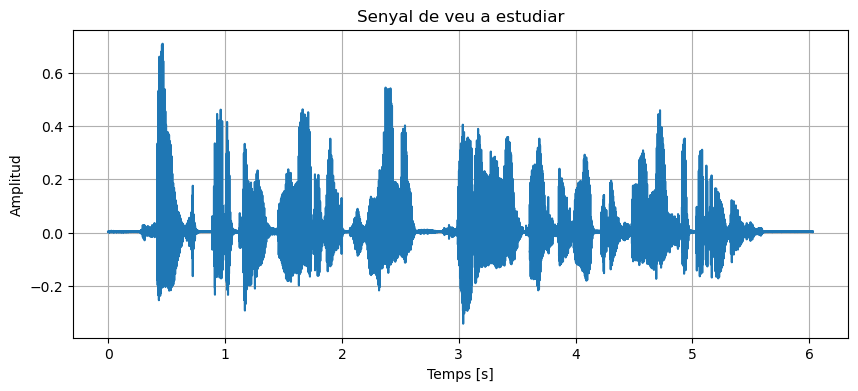

In [6]:
import numpy as np
from scipy.io import wavfile
from IPython.display import Audio
%matplotlib inline
import matplotlib.pyplot as plt

# Llegim l'àudio del disc. «fm» és la freqüència de mostratge del senyal i «frase» és la matriu que conté les mostres
FITXER_WAV = "Frase.wav"
fm, frase = wavfile.read(FITXER_WAV)

# Els valors continguts en el fitxer d'àudio són enters de 16 bits amb signe,
# això els normalitza a l'interval [-1..+1) i els converteix a coma flotant.
frase = frase / 2**15

# Pintem la forma d'ona. Abans creem un vector de temps adient, 
# tenint en compte que la separació entre mostres és T=1/fm
t = np.arange(len(frase))/fm

# Assignem els resultats de les funcions a la «variable» "_" per evitar que s'imprimeixin per pantalla
plt.rcParams['figure.figsize'] = [10, 4]
fig,ax = plt.subplots()
_ = ax.plot(t,frase)
_ = ax.grid()
_ = ax.set_title('Senyal de veu a estudiar')
_ = ax.set_ylabel('Amplitud')
_ = ax.set_xlabel('Temps [s]')  

In [8]:
# Reproduïm la frase
frase = frase.astype(np.float32)           # Important en sistemes windows si volguéssim gravar l'àudio en un fitxer .WAV
Audio(frase,rate=fm, autoplay=False)

Dins del Jupyter, obriu el _notebook_ anomenat «Analitzador» en una altra pestanya i executeu-lo. Us ha d'aparèixer una finestra amb un conjunt de gràfiques i controls:

* La gràfica superior mostra el senyal de veu en el seu conjunt, amb una franja de color taronja que ressalta el tram a analitzar
* La gràfica central és un _zoom_ del tram a analitzar.
* La gràfica inferior mostra l'__autocorrelació del tram__, normalitzada per tal que el màxim sigui sempre = 1.
* A baix a l'esquerra hi ha uns botons que permeten seleccionar la «finestra» que s'aplicarà al senyal. L'objectiu de l'enfinestrat s'anirà veient poc a poc i completant en pràctiques posteriors. En aquesta pràctica treballarem amb la finestra de HAMMING i no la tocarem, tot i que podeu escollir-ne una altra per veure momentàniament les diferències.
* A baix a la dreta hi ha una barra de desplaçament mitjançant la qual podem seleccionar un dels trams del senyal de veu per visualitzar-lo i analitzar-lo. Cada tram té una durada de 30 milisegons i pot començar en múltiples de 15 milisegons, de manera que se solapa 15ms amb el tram anterior.
* Finalment, al dessota de la barra de desplaçament veiem informació sobre el senyal, <span style="color:red">__que haureu de completar vosaltres__</span>.

<span style="color:red">Podeu canviar el tram actual movent la barra de desplaçament amb el ratolí o bé utilitzant les tecles ⬅ i ➡.</span>

---

# <span style="color:#BB44DD">Part B: Anàlisi matemàtica dels diferents trams</span>

En aquesta segona part de l'estudi previ l'objectiu és fer els càlculs necessaris _en cadascun dels segments o trams en què dividim la veu_ per tal de determinar alguns paràmetres essencials:

1. L'energia del senyal contingut en el tram de veu
2. Si el senyal correspon a un fonema __sord__ o __sonor__.
3. En cas que el fonema sigui __sonor__, determinar la freqüència de vibració de les cordes vocals.

Tot l'anterior ho farem directament modificant el codi de l'Analitzador que heu utilitzat a l'apartat A. 

## <span style="color:red">__Qüestió 2__</span> - Càlcul de l'energia del senyal del tram

Modifiqueu el codi de la funció `analitza_segment` de l'analitzador per tal d'assignar a la variable _E_ el valor de l'energia del tram. Un cop fet, reinicieu l'analitzador i comproveu que l'energia calculada es mostra a la part inferior dreta de la finestra. Aleshores procediu a respondre la pregunta 2 del qüestionari.

## <span style="color:red">__Qüestió 3__</span> - Autocorrelació de senyals periòdics

A continuació ens interessarà determinar si el tram de senyal analitzat és __sord__ o __sonor__. Del que s'ha explicat anteriorment es pot inferir que si s'està emetent un fonema __sonor__ les cordes vocals estan __vibrant__ i, per tant, el senyal produït presentarà algun tipus de __periodicitat__. En aquest cas, l'autocorrelació és una eina excel·lent per detectar i mesurar aquestes periodicitats, i a continuació en veiem els motius.

Suposem que $p[n]$ és un pols, i que anomenem $r_{pp}[n]$ a la seva autocorrelació. Suposem que amb aquest pols individual construïm un senyal format per una successió de 3 polsos espaiats $N$ mostres, és a dir,
$$ s[n] = p[n] + p[n-N] + p[n-2N] $$

Es demana que expresseu l'autocorrelació de $s[n]$, $r_{ss}[n]$ en funció de l'autocorrelació del pols individual, $r_{pp}[n]$, i que escolliu la resposta correcta a la pregunta 3 del qüestionari.

## <span style="color:red">__Qüestió 4__</span> - Sonoritat

A efectes d'aquesta pràctica considerarem que un tram de senyal és __sonor__ si compleix les següents condicions:

1. Si l'autocorrelació presenta un o més màxims locals diferents del de l'origen. Tingueu en compte que el màxim d'autocorrelació, $r_{ss}[0]$, s'obté al _centre_ del vector.
2. Que el __més gran__ d'aquests màxims locals estigui a una distància __N ≥ a 10 mostres__ del centre i que tingui una amplitud relativa al màxim de l'autocorrelació superior a 0,5, és a dir, $r_{ss}[N]/r_{ss}[0] > 0,\!5$.
3. Si l'energia _E_ del senyal del tram és __superior a 0,3__.

Modifiqueu el codi de la funció `analitza_segment` per tal d'assignar a la variable `maxims` dos vectors que continguin els índexs i valors dels màxims de l'autocorrelació que compleixen les condicions 1) i 2) anteriors. Suggerim utilitzar la funció `find_peaks` del paquet `SciPy.Signal` per tal de cercar els màxims, passant-li els paràmetres adients. 

Fet això, assigneu a la variable `sonor`el valor `True`o `False`.

Reinicieu l'analitzador per tal de verificar que no teniu errors al codi i comproveu que a la part inferior dreta de la finestra es mostra si el tram que escolliu és sonor o no. Aleshores procediu a respondre la pregunta 4 del qüestionari.

## <span style="color:red">__Qüestió 5__</span> - Freqüència de vibració

A la qüestió 3 s'ha vist que l'autocorrelació d'un senyal periòdic de període $N$ mostres presentarà __màxims__ a una distància de $\pm N,\,\pm 2N,\dots$ mostres del centre. Això és així perquè quan desplacem un senyal periódic un nombre de mostres igual a la seva periodicitat, el senyal torna a assemblar-se a sí mateix i per tant l'autocorrelació torna a ser màxima.

Aquesta propietat serà útil per a determinar la freqüència de vibració de les cordes vocals. A tal efecte:

* __Penseu un algorisme__ que calculi la separació $N$ (en mostres) entre el màxim a l'origen i el següent màxim més gran, descartant els màxims locals de menor amplitud que hi pugui haver entre ells.
* Convertiu aquesta separació en mostres a separació en segons i, d'aquí a freqüència, consignant aquest darrer valor a la variable « _f_ » de la funció `analitza_segment` de l'Analitzador de veu.

Reinicieu l'analitzador per tal de verificar que no teniu errors al codi i comproveu que a la part inferior dreta de la finestra es mostra la freqüència calculada. Aleshores procediu a respondre la pregunta 5 del qüestionari.

## <span style="color:red">__Qüestió 6__</span> - Codi de la funció `analitza_segment`

En el quadre de text de la pregunta, copieu-hi TOT el contingut de la funció «analitza_segment», amb les modificacions que hi heu fet per tal de calcular els valors i paràmetres que es demanen a les qüestions precedents.

---

# <span style="color:#BB44DD">Part C: Síntesi de veu</span>

En la darrera part de l'estudi previ l'objectiu és provar de __generar veu de forma artificial__.

Si volem generar veu sintètica que simuli el millor possible la veu real hem d'aconseguir crear un sistema que generi un senyal amb la __mateixa forma__ que el senyal de veu. Evidentment, com que ja hem vist que el senyal de veu canvia de forma tram a tram, caldrà crear un sistema nou per cada tram. Per tal de fer el problema abordable, __primer farem la síntesi per un sol tram de veu__ i durant la sessió pràctica ho estendrem a la resta de trams.

## Model matemàtic de la producció de veu

Un model matemàtic molt simplificat per a emular el sistema de producció de fonemes consisteix considerar el senyal produït pels pulmons i/o les cordes vocals com una excitació $x[n]$, i els tractes vocal i nasal com un sistema lineal o __filtre__ que modifica aquesta excitació per tal d'obtenir el so desitjat, de tal manera que:

1. Modelem el senyal $x[n]$ com un __tren de polsos__ si el so produït és __sonor__, o com a __soroll__ si el so és __sord__.
2. Com hem dit abans, els tractes vocal i nasal els modelem amb un filtre que té en compte les ressonàncies d'aquestes cavitats. Matemàticament això es pot aconseguir amb un filtre de tipus __autoregressiu__ d'ordre $P$, cosa que significa que _la sortida en un instant donat és una combinació del valor actual de l'excitació i dels $P$ valors anteriors de la pròpia sortida_. Matemàticament:
$$y[n] = b\cdot x[n] - \sum_{k=1}^P a_k\cdot y[n-k]$$
L'equació anterior es coneix com una __equació en diferències finites__ (EDF), i és una de les múltiples maneres d'expressar un sistema lineal.

Per tant, per poder produir veu de forma artificial haurem de __determinar els coeficients $a_1, \dots, a_P, b$ del filtre__ i també __escollir adequadament el senyal d'excitació $x[n]$__ segons el fonema que vulguem reproduir.

![image](Síntesi.png)

## Excitació

El tipus d'excitació que hem de posar a l'entrada del filtre dependrà de si el fonema és sonor o sord:

* Si el fonema és __sonor__, generarem una excitació consistent en un __tren de deltes__ d'amplitud $\sqrt{N}$ i separades $N$ mostres, essent $N$ és el període (en mostres) calculat a la qüestió 5.
* Si el fonema és __sord__ usarem com a excitació un generador de soroll de variància 1, per exemple gaussià blanc: `np.random.normal(...)`.

<span style="color:#DD0000;">En tots els casos la longitud de l'excitació serà de __120 mostres__ (15ms).</span>

## <span style="color:red">__Qüestió 7__</span>

Per què creieu que donem una amplitud de $\sqrt{N}$ a l'excitació sonora? Responeu-ho al qüestionari.

## Filtre (sistema lineal)

L'anàlisi de la veu hauria d'incloure el càlcul dels coeficients $b$ i $a_k$ de l'equació en diferències, però aquesta és una qüestió que ultrapassa els objectius docents del moment. Per aquest motiu, els coeficients del filtre corresponents a cadascun dels trams es proporcionen al fitxer `Coeficients_Frase.npz`, que carregareu tal com es mostra al codi del dessota.

Fet això, haureu de completar el codi següent per tal de:

1. Escollir un tram de veu de 15 ms de durada.
2. Llegir el tram de veu.
3. Generar una excitació x[n] adequada en funció de si el tram escollit és sord o sonor.

La resta de codi ja està programada (no cal que feu res) i consisteix en generar la veu sintetitzada usant l'excitació que heu generat i comparar visualment el resultat amb la veu original.

In [ ]:
# Carreguem els coeficients del filtre en cada tram.
# Construïm el nom del fitxer de coeficients
base,extensio = FITXER_WAV.split('.', 1)
fitxer_coef = "Coeficients_" + base + '.npz'
# Carrueguem amb gestió d'excepcions
with np.load(fitxer_coef) as coef:
    a = coef['a']       # a[k] contindrà els coeficients a1..aP del tram «k»
    b = coef['b']       # b[k] contindrà el coeficient b del tram «k»

# ATENCIÓ: Usarem una longitud del tram de síntesi de 120 mostres (15ms), i no 240 (30ms), perquè en l'anàlisi els trams se solapaven 15ms.
Ls = 120

# Completeu el codi per tal de sintetitzar i visualitzar el senyal corresponent al tram de veu que us agradi més
# Com a suggerència, podeu provar els trams 30, 47, 62, 81, 88, 105, 154, 163, 241, 250 o 261
tram =  
veu_original = frase[.......] 

# Decidireu la sonoritat en funció de l'anàlisi del senyal fet anteriorment
sonor =        # Ha de ser «True» o «False»

if sonor:
    # Genereu l'excitació sonora
    x = 
else:
    # Genereu l'excitació sorda
    x = 

# Finalment fem passar l'excitació a través del filtre per tal d'obtenir la veu sintetitzada
# Això ho farem amb la funció «lfilter», que treballarem més en pràctiques posteriors
from scipy.signal import lfilter
veu_sintetitzada = lfilter(b[tram], a[tram], x)

# Presenteu en un gràfic el tram de veu original i el sintetitzat, per tal de poder-los comparar
%matplotlib qt
fig, (ax1, ax2) = plt.subplots(2,1,sharex=True, sharey=True)
t = np.arange(Ls)/fm
ax1.plot(t,veu_original, color='C2')
ax1.grid(True, which='both', axis='both')
ax1.set_title('Comparació entre veu real i sintètica')
ax1.set_ylabel('Veu real')

ax2.plot(t,veu_sintetitzada)
ax2.grid(True, which='both', axis='both')
ax2.set_ylabel('Veu sintètica')
ax2.set_xlabel('Temps [s]')

---

# <span style="color:#BB44DD">Part D: Síntesi de la frase completa</span>

La frase completa la sintetitzarem generant artificialment cadascun dels trams del senyal de veu i concatenant-los tots procurant que les transicions no presentin salts bruscs i siguin el més suaus possible.

Aquesta part la farem presencialment al laboratori.